In [201]:
import seaborn as  sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from packaging import markers

In [202]:
path = r"C:\WEC_Analysis\Data\raw\wec_data.csv"

df = pd.read_csv(path)
df

,car,overall_position,class_position,team,vehicle,class,group,race,event_duration,season,...,gap_first,gap_car_ahead,tyres,status,fl_lap_number,fl_time,fl_kph_average,driver_1,driver_2,driver_3
0,Toyota Racing #8,1,1,Toyota Racing,Toyota TS 040 - Hybrid,LMP1,H,Silverstone,6,2014,...,NaN,NaN,Michelin,Classified,112.0,1:44.646,202.7,Anthony DAVIDSON,Nicolas LAPIERRE,Sébastien BUEMI
1,Toyota Racing #7,2,2,Toyota Racing,Toyota TS 040 - Hybrid,LMP1,H,Silverstone,6,2014,...,1 Laps,1 Laps,Michelin,Classified,17.0,1:44.326,203.3,Alexander WURZ,Stéphane SARRAZIN,Kazuki NAKAJIMA
2,Porsche Team #20,3,3,Porsche Team,Porsche 919 Hybrid,LMP1,H,Silverstone,6,2014,...,2 Laps,1 Laps,Michelin,Classified,4.0,1:45.245,201.5,Timo BERNHARD,Mark WEBBER,Brendon HARTLEY
3,Rebellion Racing #12,4,4,Rebellion Racing,Lola B12/60 - Toyota,LMP1,L,Silverstone,6,2014,...,8 Laps,6 Laps,Michelin,Classified,5.0,1:47.195,197.8,Nicolas PROST,Nick HEIDFELD,Mathias BECHE
4,G-Drive Racing #26,5,1,G-Drive Racing,Morgan - Nissan,LMP2,NaN,Silverstone,6,2014,...,13 Laps,5 Laps,Dunlop,Classified,3.0,1:51.339,190.5,Roman RUSINOV,Olivier PLA,Julien CANAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3030,Krohn Racing #57,24,8,Krohn Racing,Ferrari F458 Italia,LMGTE Am,NaN,Cota,6,2013,...,31 Laps,6 Laps,Michelin,Classified,110.0,2:06.558,156.9,Tracy KROHN,Niclas JÖNSSON,Maurizio MEDIANI
3031,OAK Racing #45,25,8,OAK Racing,Morgan - Nissan,LMP2,NaN,Cota,6,2013,...,39 Laps,8 Laps,Dunlop,Classified,86.0,1:59.816,165.7,Jacques NICOLET,Jean-Marc MERLIN,Erik MARIS
3032,Aston Martin Racing #97,26,6,Aston Martin Racing,Aston Martin Vantage V8,LMGTE Pro,NaN,Cota,6,2013,...,69 Laps,30 Laps,Michelin,Classified,109.0,2:04.298,159.8,Stefan MÜCKE,Darren TURNER,Oliver GAVIN
3033,Aston Martin Racing #98,27,7,Aston Martin Racing,Aston Martin Vantage V8,LMGTE Pro,NaN,Cota,6,2013,...,103 Laps,34 Laps,Michelin,Classified,50.0,2:04.292,159.8,Paul DALLA LANA,Pedro LAMY,Richie STANAWAY


In [203]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3035 entries, 0 to 3034
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car               3035 non-null   object 
 1   overall_position  3035 non-null   int64  
 2   class_position    3035 non-null   int64  
 3   team              3035 non-null   object 
 4   vehicle           3035 non-null   object 
 5   class             3035 non-null   object 
 6   group             428 non-null    object 
 7   race              3035 non-null   object 
 8   event_duration    3035 non-null   int64  
 9   season            3035 non-null   object 
 10  laps              3035 non-null   int64  
 11  total_time        3026 non-null   object 
 12  gap_first         2948 non-null   object 
 13  gap_car_ahead     2946 non-null   object 
 14  tyres             3035 non-null   object 
 15  status            3035 non-null   object 
 16  fl_lap_number     3022 non-null   float64


In [204]:
df['class'].unique()
df['class'] = df['class'].replace({
    'LM P1' : 'LMP1',
    'LM P2' : 'LMP2',
    'LM GTE Pro' : 'LMGTE Pro',
    'LM GTE Am' : 'LMGTE Am',
    'CDNT' :'Experimental',
    'INNOVATIVE CAR' : 'Experimental'
})
df['class'].unique()
df['class'].value_counts()

class
LMP2            977
LMGTE Am        843
LMGTE Pro       579
LMP1            491
HYPERCAR        140
Experimental      5
Name: count, dtype: int64

In [205]:
df.info()
class_map = {
    'LMP1' : 'Hypercar',
    'LMH' : 'Hypercar',
    'LMDh' : 'Hypercar',
    'HYPERCAR' : 'Hypercar',
    'LMP2' : 'LMP2',
    'LMGTE Am' : 'LMGT3',
    'LMGTE Pro' : 'LMGT3',
    'CDNT' : 'Experimental',
    'INNOVATIVE CAR' : 'Experimental'
}
df['class_group'] = df['class'].map(class_map)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3035 entries, 0 to 3034
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car               3035 non-null   object 
 1   overall_position  3035 non-null   int64  
 2   class_position    3035 non-null   int64  
 3   team              3035 non-null   object 
 4   vehicle           3035 non-null   object 
 5   class             3035 non-null   object 
 6   group             428 non-null    object 
 7   race              3035 non-null   object 
 8   event_duration    3035 non-null   int64  
 9   season            3035 non-null   object 
 10  laps              3035 non-null   int64  
 11  total_time        3026 non-null   object 
 12  gap_first         2948 non-null   object 
 13  gap_car_ahead     2946 non-null   object 
 14  tyres             3035 non-null   object 
 15  status            3035 non-null   object 
 16  fl_lap_number     3022 non-null   float64


<Axes: xlabel='class_group', ylabel='count'>

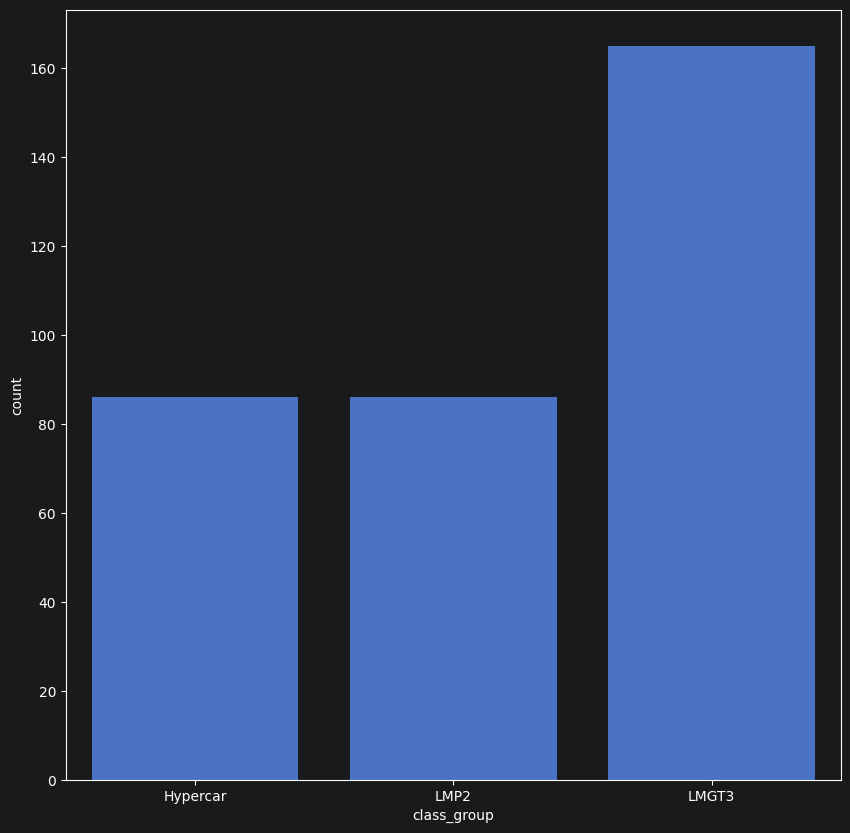

In [206]:
winners = df[df['class_position'] == 1]
victory_counts = winners['class_group'].value_counts()
plt.figure(figsize=(10,10))
sns.countplot(data=winners, x='class_group')

Seperti yang kita lihat, disini kelas LMGT3 yang dimana saya gabungkan (LMGTE Am dan LMGTE Pro) mendominasi di chart, disini diakibatkan adanya dua pemenang dalam season race sebagai pemenang kelas LMGTE Pro dan Am. Lalu jumlah mobil LMGT yang bersaing lebih banyak dibanding semua kelas (LMP2 dan Hypercar)

<Axes: xlabel='class', ylabel='count'>

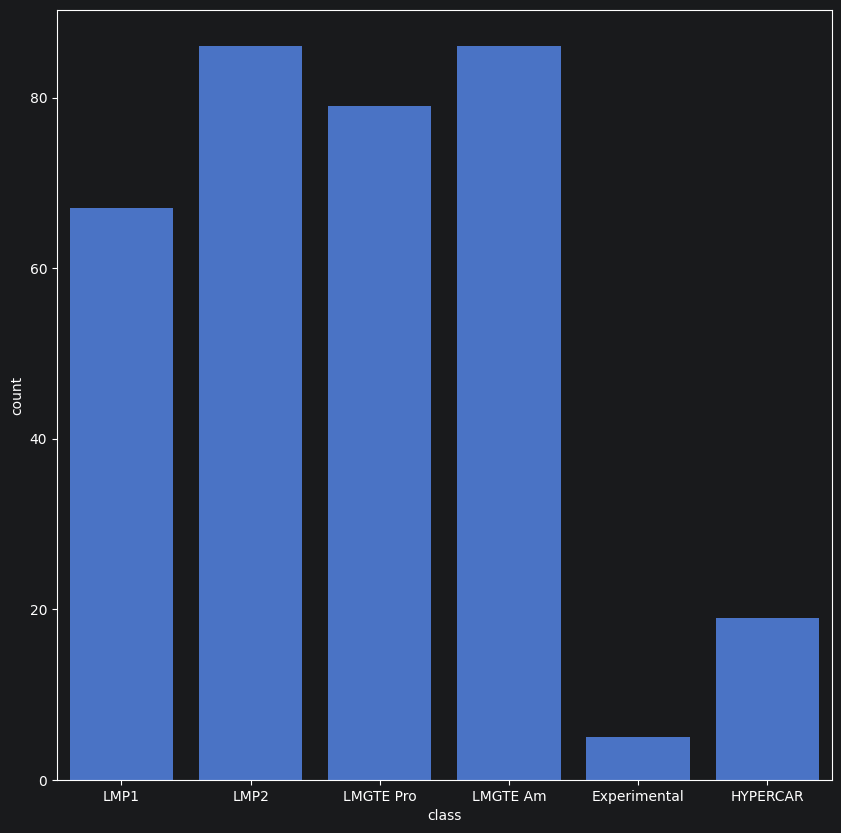

In [207]:
plt.figure(figsize=(10,10))
sns.countplot(winners, x='class')

In [208]:
check_winners = winners.groupby(['season', 'race', 'class_group']).size().reset_index(name='winner_count')
print(check_winners[check_winners['winner_count'] > 1].head())

   season        race class_group  winner_count
1    2011      LeMans       LMGT3             2
4    2012     Bahrain       LMGT3             2
7    2012        Fuji       LMGT3             2
10   2012  Interlagos       LMGT3             2
13   2012      LeMans       LMGT3             2


In [209]:
df['class'].unique()

array(['LMP1', 'LMP2', 'LMGTE Pro', 'LMGTE Am', 'Experimental',
       'HYPERCAR'], dtype=object)

In [210]:
df['team']=df['team'].str.replace('Toyota Racing', 'Toyota Gazoo Racing')


In [211]:
hypercar_winners = df[(df['class_group'] == 'Hypercar') & df['class_position'] == 1]
top_hypercar_teams = hypercar_winners[['team']].value_counts()
top_hypercar_teams

team                     
Toyota Gazoo Racing          83
Audi Sport Team Joest        53
Rebellion Racing             51
Porsche Team                 29
Bykolles Racing Team         12
Peugeot TotalEnergies        10
Glickenhaus Racing           10
Porsche LMP Team             10
SMP Racing                   10
Porsche Penske Motorsport     8
Ferrari AF Corse              8
Strakka Racing                6
Alpine ELF Team               5
JRM                           5
Cadillac Racing               4
Alpine Elf Matmut             4
Pescarolo Team                4
Lotus                         4
Oak Racing                    3
Team Bykolles                 3
Floyd Vanwall Racing Team     3
Audi Sport North America      3
Hertz Team JOTA               2
Nissan Motorsports            2
Team LNT                      2
Proton Competition            2
Aston Martin Racing           1
CEFC TRSM Racing              1
Kronos Racing                 1
DragonSpeed                   1
Peugeot Sport 

<Axes: xlabel='season'>

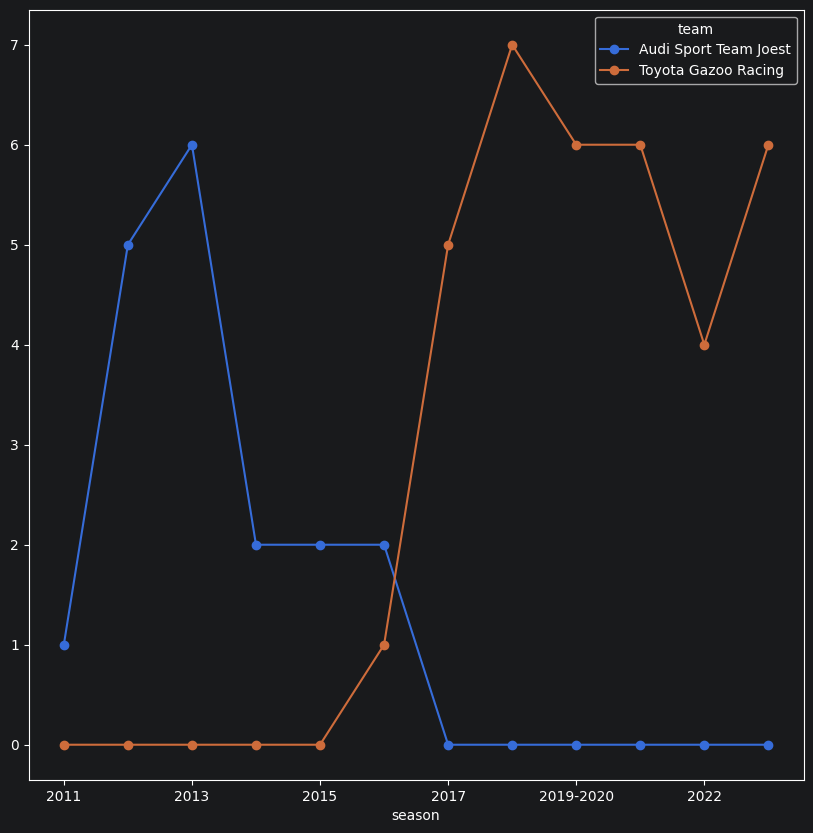

In [212]:
top_hypercar_winners = winners[winners['team'].isin(['Toyota Gazoo Racing', 'Audi Sport Team Joest'])]
hypercar_trend_data = top_hypercar_winners.groupby(['season', 'team']).size().unstack().fillna(0)

hypercar_trend_data.plot(kind='line', marker='o', figsize=(10,10))

In [213]:
LMGT3_winners = df[(df['class_group'] == 'LMGT3') & df['class_position'] == 1]
top_LMGT3_winners = LMGT3_winners[['team']].value_counts()
top_LMGT3_winners

team                   
AF Corse                   160
Aston Martin Racing        129
Dempsey - Proton Racing     46
Porsche GT Team             42
Team Project 1              25
                          ... 
Robertson Racing LLC         1
SRT Motorsports              1
Team AAI                     1
Team Sofrev ASP              1
WeatherTech Racing           1
Name: count, Length: 72, dtype: int64

<Axes: xlabel='season'>

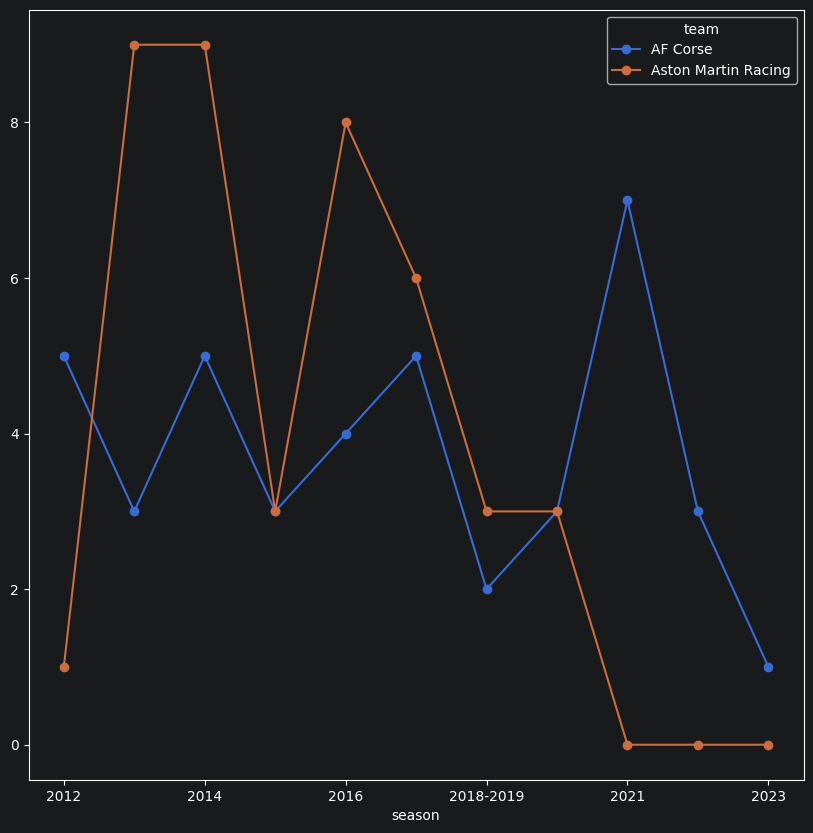

In [214]:
top_two = winners[winners['team'].isin(['AF Corse', 'Aston Martin Racing'])]
trend_data = top_two.groupby(['season', 'team']).size().unstack().fillna(0)

display(trend_data.plot(kind='line', marker='o', figsize=(10,10)))

In [215]:
df.groupby('class_group')['tyres'].value_counts()

class_group  tyres   
Hypercar     Michelin     601
             Dunlop        30
LMGT3        Michelin    1328
             Dunlop        85
             Pirelli        8
             Hankook        1
LMP2         Dunlop       535
             Goodyear     295
             Michelin     147
Name: count, dtype: int64

<Axes: xlabel='class_group', ylabel='tyres'>

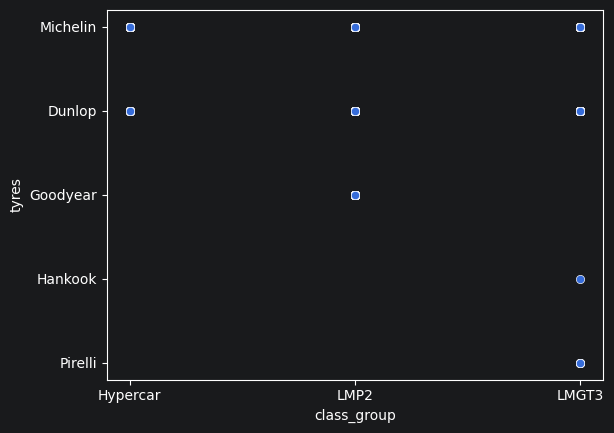

In [216]:
sns.scatterplot(df, x='class_group', y='tyres')

In [217]:
def lap_to_seconds(lap_time):
    try:
        if pd.isna(lap_time) or lap_time == '-':
            return None
        minutes, seconds = lap_time.split(':')
        return int(minutes) * 60 + float(seconds)
    except:
        return None

df ['fastest_lap (seconds)'] = df['fl_time'].apply(lap_to_seconds)
df[['fastest_lap (seconds)']]

,fastest_lap (seconds)
0,104.646
1,104.326
2,105.245
3,107.195
4,111.339
...,...
3030,126.558
3031,119.816
3032,124.298
3033,124.292


In [218]:
df['race'] = df['race'].replace({
    'LeMans 1' : 'LeMans',
    'LeMans 2' : 'LeMans',
    'Bahrain 2' : 'Bahrain',
    'Spa 2' : 'Spa'
})

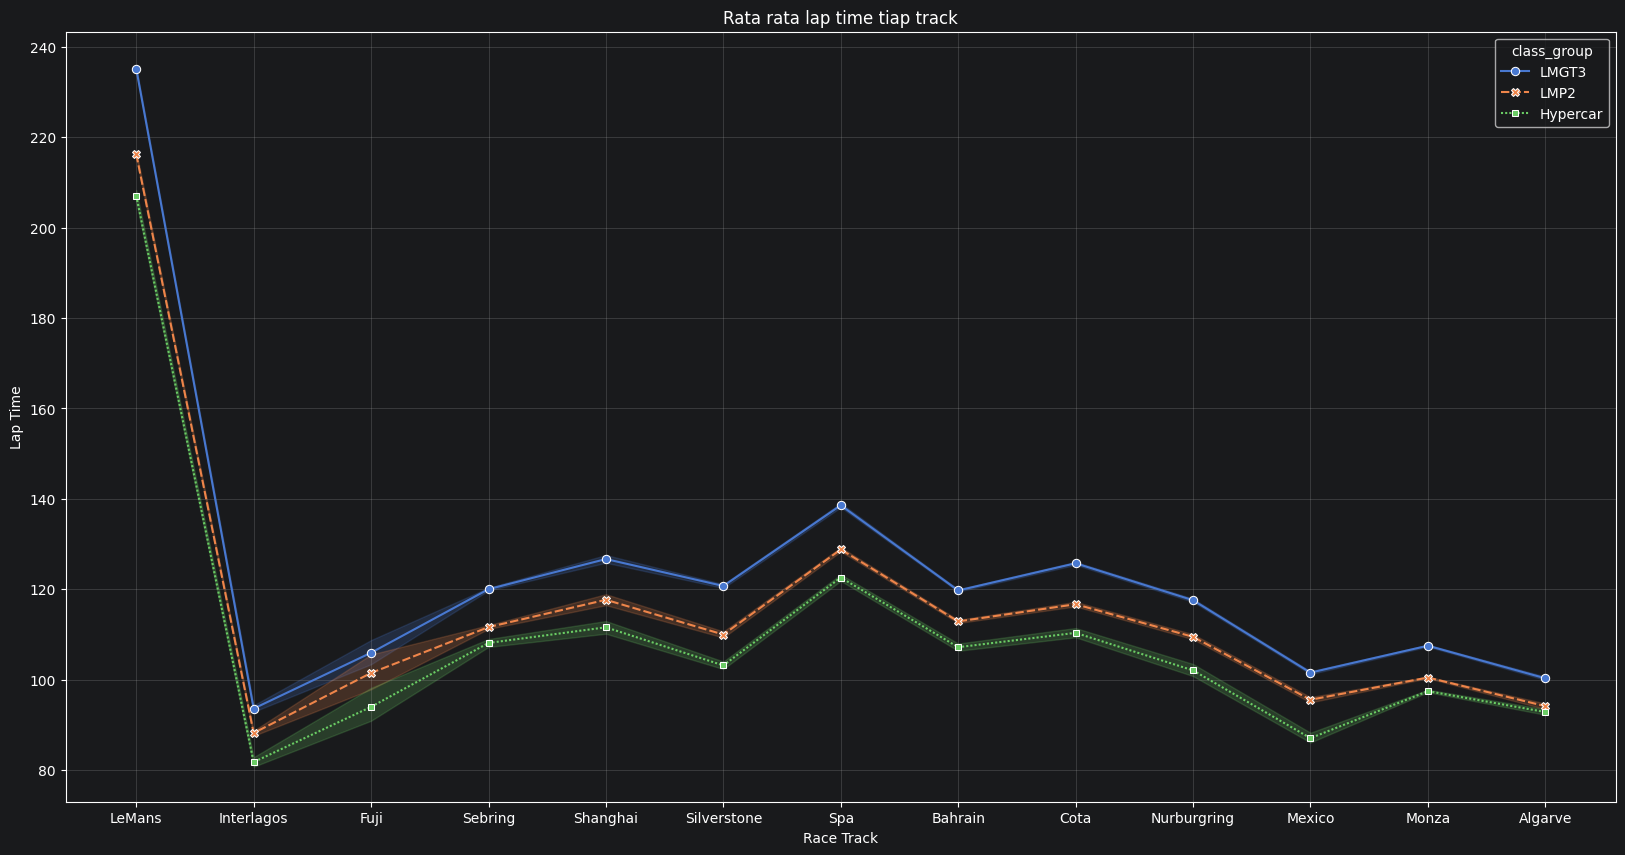

In [219]:
df_sorted = df.sort_values('season')
plt.figure(figsize=(20,10))
ax = sns.lineplot(
    data=df_sorted,
    x='race',
    y='fastest_lap (seconds)',
    hue='class_group',
    markers=True,
    style = 'class_group',
    dashes=True,
    palette='muted'
)

plt.title("Rata rata lap time tiap track")
plt.ylabel("Lap Time")
plt.xlabel("Race Track")
plt.grid(True, alpha=0.3)

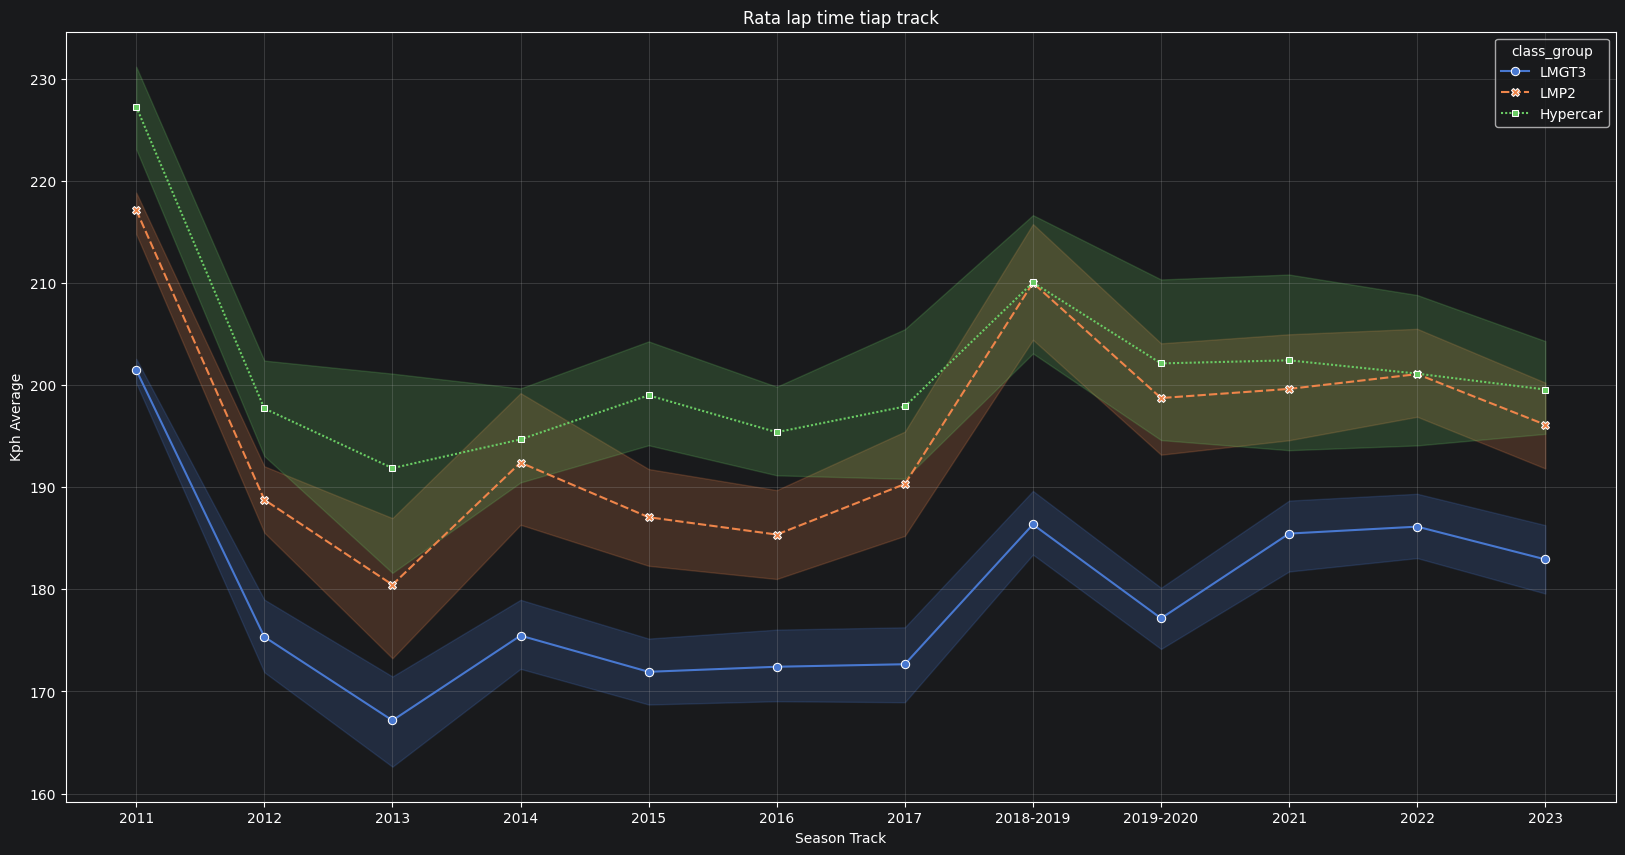

In [220]:
df_sorted = df.sort_values('season')
plt.figure(figsize=(20,10))
ax = sns.lineplot(
    data=df_sorted,
    x='season',
    y='fl_kph_average',
    hue='class_group',
    markers=True,
    style = 'class_group',
    dashes=True,
    palette='muted'
)
plt.title("Rata lap time tiap track")
plt.ylabel("Kph Average")
plt.xlabel("Season Track")
plt.grid(True, alpha=0.3)

Text(0.5, 1.0, 'Rata rata kecepatan tiap race tiap kelas')

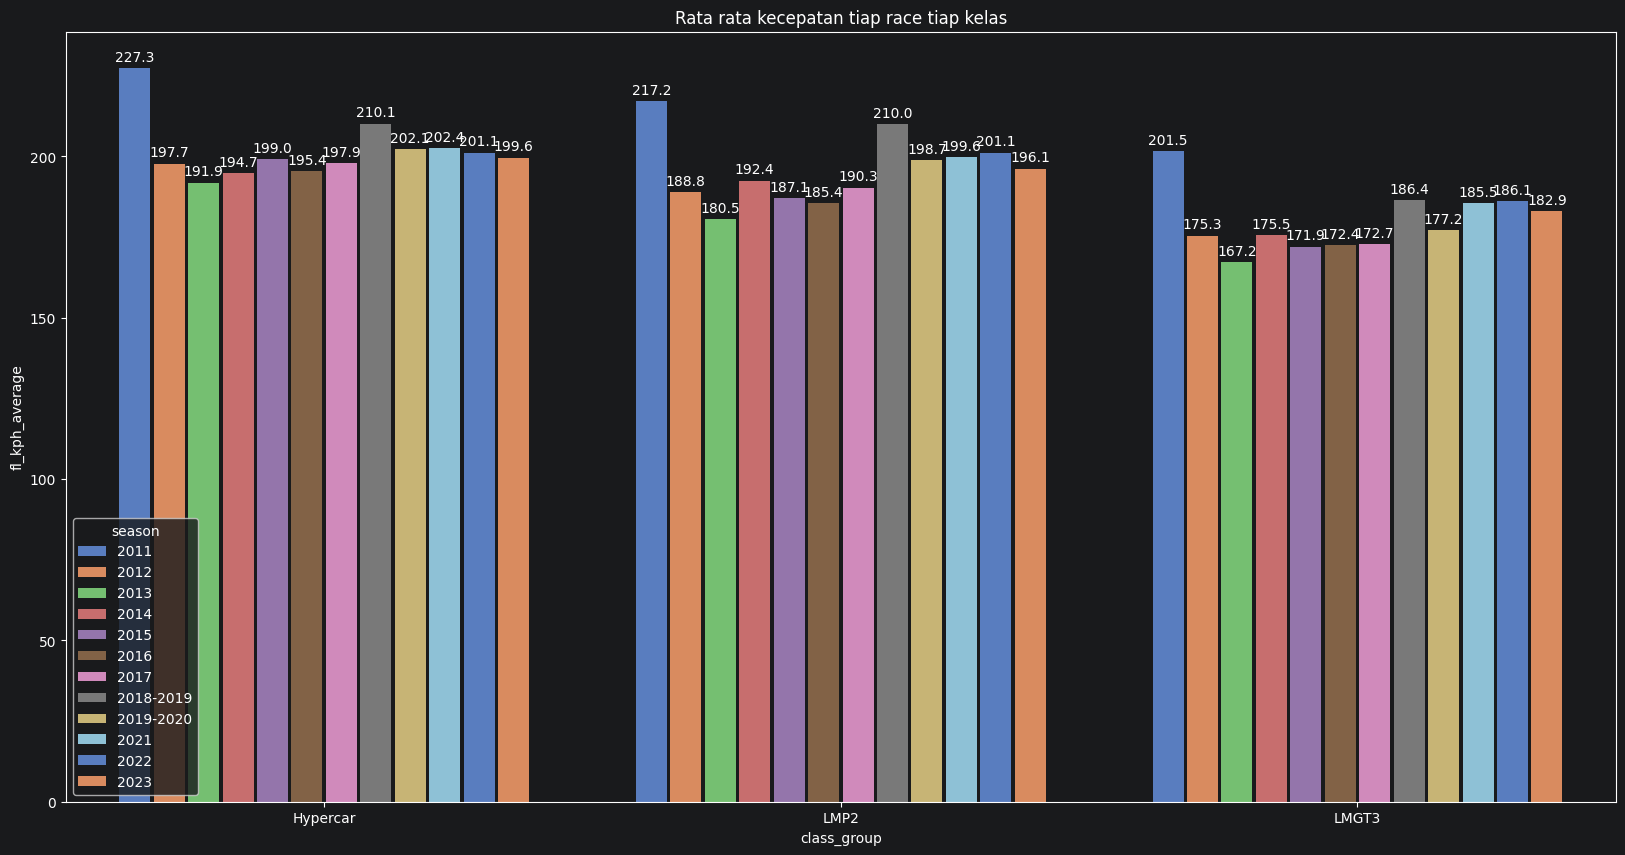

In [221]:
automatic_order2 = df.groupby('class_group')['fl_kph_average'].mean().sort_values(ascending=False).index
year_order = sorted(df['season'].unique())
plt.figure(figsize=(20,10))
ax = sns.barplot(data=df,x='class_group', y='fl_kph_average', errorbar=None, hue='season',hue_order=year_order, gap=0.1, palette='muted', order=automatic_order2)

for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='%0.1f')
plt.title("Rata rata kecepatan tiap race tiap kelas")

In [222]:
# Cek nama kelas asli yang ada di tahun 2021 dan 2023
print("Kelas di tahun 2021:")
print(df[df['season'] == '2021']['class'].unique())

print("\nKelas di tahun 2023:")
print(df[df['season'] == '2023']['class'].unique())

Kelas di tahun 2021:
['HYPERCAR' 'LMP2' 'LMGTE Pro' 'LMGTE Am' 'Experimental']

Kelas di tahun 2023:
['HYPERCAR' 'LMP2' 'LMGTE Am' 'Experimental']


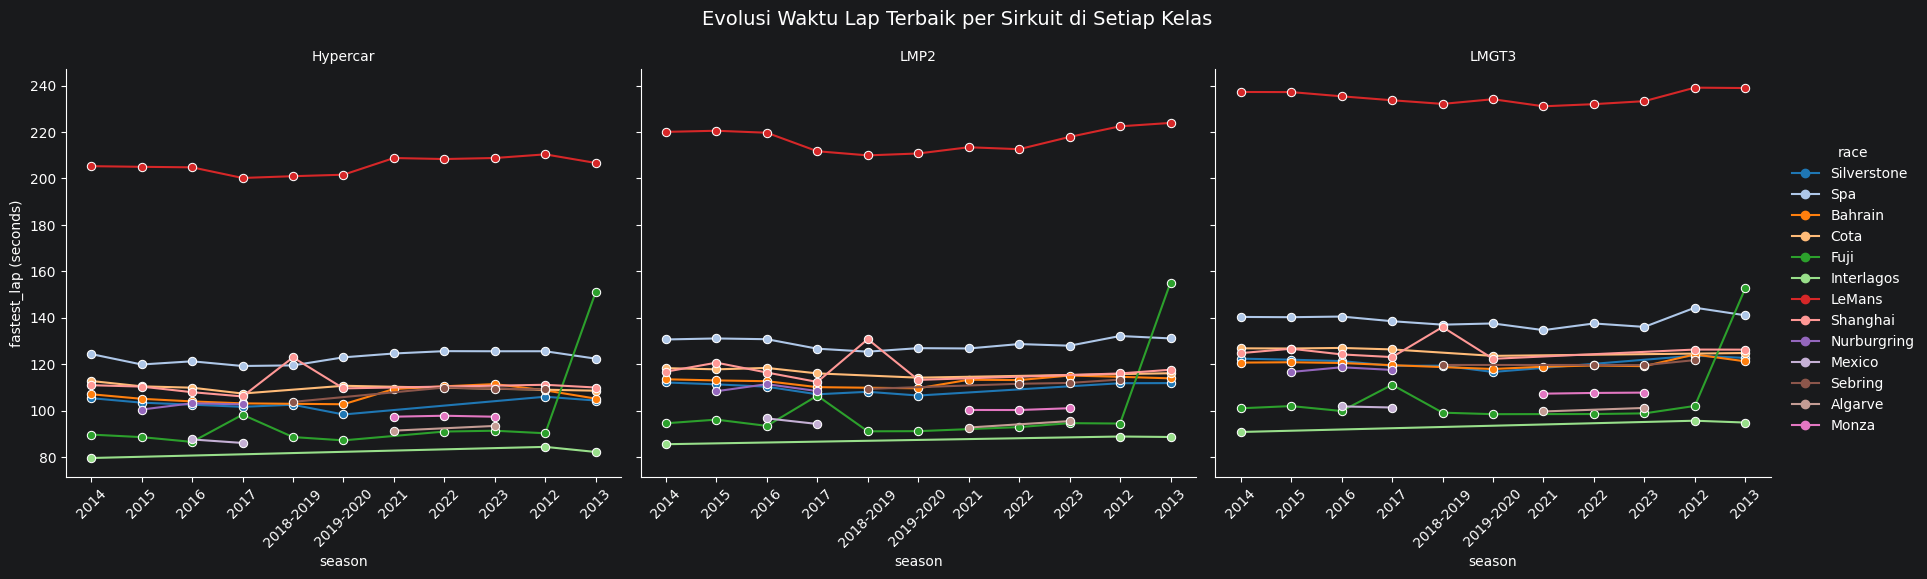

In [223]:
df_official_wec = df[(df['season'] >= '2012')]
df_official_wec.sort_values('season')
fastest_lap_each_year = df_official_wec.groupby(['season', 'class_group', 'race'])[['fastest_lap (seconds)', 'vehicle']].min()
fastest_lap_each_year

g = sns.relplot(
    data=df_official_wec,
    x='season',
    y='fastest_lap (seconds)',
    hue='race',
    col='class_group',
    kind='line',
    marker='o',
    palette='tab20',
    height=5,
    aspect=1.2,
    errorbar=None
)
g.fig.suptitle("Evolusi Waktu Lap Terbaik per Sirkuit di Setiap Kelas", y=1.05, fontsize=14)
g.set_titles("{col_name}")
g.set_xticklabels(rotation=45)

plt.show()

In [238]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

juara_1_df = df[df['class_position'] == 1]
car_dominator_yearly = juara_1_df.groupby(['season', 'class_group', 'vehicle']).size().reset_index(name="total Win")

idx_terbanyak = car_dominator_yearly.groupby(['season', 'class_group'])['total Win'].idxmax()
top_car_yearly = car_dominator_yearly.loc[idx_terbanyak]

top_car_yearly

,season,class_group,vehicle,total Win
0,2011,Hypercar,Audi R18 TDI,1
1,2011,LMGT3,Chevrolet Corvette C6 ZR1,2
2,2011,LMP2,Zytek Nissan,1
5,2012,Hypercar,Audi R18 e-tron quattro,3
12,2012,LMGT3,Porsche 911 RSR (997),6
14,2012,LMP2,Oreca 03 - Nissan,4
16,2013,Hypercar,Audi R18 e-tron quattro,6
18,2013,LMGT3,Aston Martin Vantage V8,9
23,2013,LMP2,Oreca 03 - Nissan,6
26,2014,Hypercar,Toyota TS 040 - Hybrid,5
